# Gradient Boosting – End‑to‑End Revision Notes (Simple & Clear)

---

## 1. What is Gradient Boosting?

Gradient Boosting is a **machine learning technique** that builds a **strong model by combining many weak models** (usually small decision trees).

Key idea:

> **Each new model tries to correct the mistakes (errors) made by the previous models.**

It works **sequentially**, not in parallel.

---

## 2. Why Do We Need Gradient Boosting?

Simple models (like Linear Regression):

* Cannot capture complex, non‑linear patterns

Single Decision Tree:

* Overfits easily
* High variance

Random Forest:

* Reduces variance
* But does NOT focus on hard‑to‑predict points

Gradient Boosting:
✔ Focuses on **errors**
✔ Handles **non‑linear relationships**
✔ Very high accuracy on **tabular data**

---

## 3. Core Intuition (MOST IMPORTANT)

Gradient Boosting is:

> **Gradient Descent, but in function space**

Instead of updating numbers (weights), we keep **adding models** to reduce loss.

---

## 4. Basic Workflow (High Level)

1. Start with a simple initial prediction
2. Calculate errors (residuals)
3. Train a weak decision tree on these residuals
4. Add this tree to the model (with a learning rate)
5. Repeat until improvement stops

---

## 5. Initial Model (F₀)

For regression (MSE loss):

Initial prediction is the **mean of target values**:

F₀(x) = mean(y)

This is the best constant prediction.

---

## 6. Residuals (Errors)

Residual means **what is still not predicted by the current model**.

For regression with Mean Squared Error (MSE):

residualᵢ = yᵢ − Fₘ(xᵢ)

Important:

* Residual is always calculated using the **current model prediction**
* Residuals guide the next decision tree

---

## 7. Role of Decision Trees

In Gradient Boosting:

* Trees are **weak learners**
* Trees are **shallow** (depth 1–3)

Each tree:

> Learns a simple pattern in the residuals

We intentionally **stop tree growth early** to avoid overfitting.

---

## 8. Sequential Learning Process (STEP-BY-STEP)

This is the **exact manual process** you were asking for.

### Step 1: Initial Model (F₀)

* Compute mean of target values
* This mean becomes the first prediction

F₀(x) = mean(y)

---

### Step 2: First Residual (r₁)

Compute residuals using F₀:

r₁ = y − F₀(x)

These residuals show how much the mean prediction is wrong.

---

### Step 3: Train First Decision Tree

* Input (X) → original features
* Output (y) → residuals r₁

This tree learns **patterns in the residuals**.

Let the tree prediction be:

h₁(x)

---

### Step 4: Update Model to F₁

Add the tree to the model using learning rate η:

F₁(x) = F₀(x) + η · h₁(x)

---

### Step 5: Second Residual (r₂)

Compute new residuals using updated model:

r₂ = y − F₁(x)

---

### Step 6: Train Next Tree

* Train another shallow tree on (X, r₂)
* Let its prediction be h₂(x)

---

### Step 7: Update Model Again

F₂(x) = F₁(x) + η · h₂(x)

---

### Step 8: Repeat the Loop

Repeat:

* Compute residuals
* Fit tree on residuals
* Update model

Until:

* Loss improvement becomes very small
* OR validation loss stops improving

---

## 9. Learning Rate (η)

Learning rate controls **how much each tree contributes**.

Small learning rate:
✔ Better generalization
✔ Needs more trees

Large learning rate:
❌ Risk of overfitting
❌ Unstable learning

Rule:

> Smaller η → more trees → safer learning

---

## 10. Loss Function

Gradient Boosting minimizes a **loss function**.

Examples:

* Regression → Mean Squared Error (MSE)
* Classification → Log Loss

The algorithm always tries to:

> Reduce loss step by step

---

## 11. Why It’s Called “Gradient” Boosting

Gradient Boosting minimizes the loss function using **gradient descent**.

For MSE loss:

* Gradient of loss = −(y − prediction)
* Negative gradient = residual

So:

> Fitting residuals is equivalent to taking a gradient descent step.

This is why:

* We recompute residuals every iteration
* Each tree follows the direction of steepest loss reduction

---

## 12. When Do We Stop Adding Trees?

There is **no fixed number** of trees internally.

We stop when:

1. Loss improvement becomes very small
2. Validation loss stops improving (early stopping)
3. Residuals become tiny / random
4. Maximum number of trees reached (safety limit)

Stopping condition:

|Lossₘ − Lossₘ₋₁| < ε

---

## 13. Overfitting in Gradient Boosting

Overfitting happens when:

* Too many trees
* Trees too deep
* Learning rate too large

Prevention:
✔ Shallow trees
✔ Small learning rate
✔ Early stopping

---

## 14. Gradient Boosting vs Random Forest

| Aspect   | Gradient Boosting | Random Forest |
| -------- | ----------------- | ------------- |
| Training | Sequential        | Parallel      |
| Focus    | Error correction  | Averaging     |
| Bias     | Low               | Medium        |
| Variance | Can be high       | Low           |
| Accuracy | Usually higher    | Good          |

---

## 15. Real‑World Use Cases

Gradient Boosting is best for:

* Tabular data
* Business problems

Used in:

* House price prediction
* Credit scoring
* Fraud detection
* Customer churn
* Insurance risk
* Sales forecasting

---

## 16. Popular Implementations

* GradientBoosting (sklearn)
* XGBoost
* LightGBM
* CatBoost

All follow the same core idea.

---

## 17. One‑Line Summary (REMEMBER THIS)

> **Gradient Boosting builds a strong predictive model by sequentially adding weak decision trees that correct the errors of previous models using gradient descent on the loss function.**

---

## 18. How YOU Should Revise This

1. Read once fully
2. Explain steps without code
3. Connect residuals → gradients → loss
4. Then implement from scratch

If you understand this document, you do NOT need a YouTube lecture.

---

### End of Notes


In [36]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [37]:
data = {
    "size_sqft": [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400],
    "num_rooms": [1, 1, 2, 2, 2, 3, 3, 3, 4, 4],
    "price": [100, 120, 150, 180, 200, 250, 280, 300, 350, 380]
}

df = pd.DataFrame(data)
df2 = df.copy()

In [38]:
df['f0(x)'] = df['price'].mean()

In [39]:
df

,size_sqft,num_rooms,price,f0(x)
0,500,1,100,231.0
1,600,1,120,231.0
2,700,2,150,231.0
3,800,2,180,231.0
4,900,2,200,231.0
5,1000,3,250,231.0
6,1100,3,280,231.0
7,1200,3,300,231.0
8,1300,4,350,231.0
9,1400,4,380,231.0


In [40]:
#First residual .
df['ri1'] = df['price'] -df['f0(x)']

In [41]:
df

,size_sqft,num_rooms,price,f0(x),ri1
0,500,1,100,231.0,-131.0
1,600,1,120,231.0,-111.0
2,700,2,150,231.0,-81.0
3,800,2,180,231.0,-51.0
4,900,2,200,231.0,-31.0
5,1000,3,250,231.0,19.0
6,1100,3,280,231.0,49.0
7,1200,3,300,231.0,69.0
8,1300,4,350,231.0,119.0
9,1400,4,380,231.0,149.0


In [42]:
from sklearn.tree import DecisionTreeRegressor
dt1 = DecisionTreeRegressor(max_depth=2)

In [43]:
dt1.fit(df.iloc[: ,0:2].values , df['ri1'].values)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.5, 0.8333333333333334, 'x[1] <= 2.5\nsquared_error = 8349.0\nsamples = 10\nvalue = 0.0'),
 Text(0.25, 0.5, 'x[0] <= 650.0\nsquared_error = 1360.0\nsamples = 5\nvalue = -81.0'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 100.0\nsamples = 2\nvalue = -121.0'),
 Text(0.375, 0.16666666666666666, 'squared_error = 422.222\nsamples = 3\nvalue = -54.333'),
 Text(0.75, 0.5, 'x[1] <= 3.5\nsquared_error = 2216.0\nsamples = 5\nvalue = 81.0'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 422.222\nsamples = 3\nvalue = 45.667'),
 Text(0.875, 0.16666666666666666, 'squared_error = 225.0\nsamples = 2\nvalue = 134.0')]

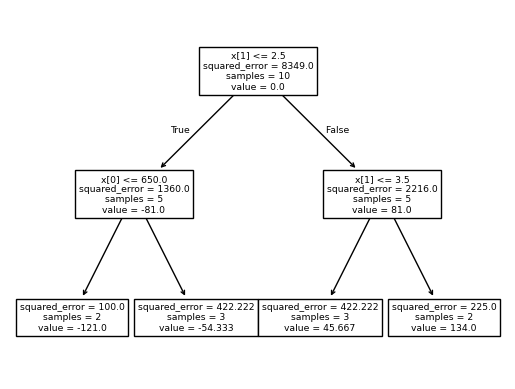

In [44]:
from sklearn.tree import plot_tree
plot_tree(dt1)

In [45]:
df['ri2'] = dt1.predict(df.iloc[: , :2])

c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


In [46]:
df

,size_sqft,num_rooms,price,f0(x),ri1,ri2
0,500,1,100,231.0,-131.0,-121.000000
1,600,1,120,231.0,-111.0,-121.000000
2,700,2,150,231.0,-81.0,-54.333333
3,800,2,180,231.0,-51.0,-54.333333
4,900,2,200,231.0,-31.0,-54.333333
5,1000,3,250,231.0,19.0,45.666667
6,1100,3,280,231.0,49.0,45.666667
7,1200,3,300,231.0,69.0,45.666667
8,1300,4,350,231.0,119.0,134.000000
9,1400,4,380,231.0,149.0,134.000000


In [47]:
learning_rate = 0.01
df['f1(x)'] = df['f0(x)'] + learning_rate * df['ri2']

In [48]:
df

,size_sqft,num_rooms,price,f0(x),ri1,ri2,f1(x)
0,500,1,100,231.0,-131.0,-121.000000,229.790000
1,600,1,120,231.0,-111.0,-121.000000,229.790000
2,700,2,150,231.0,-81.0,-54.333333,230.456667
3,800,2,180,231.0,-51.0,-54.333333,230.456667
4,900,2,200,231.0,-31.0,-54.333333,230.456667
5,1000,3,250,231.0,19.0,45.666667,231.456667
6,1100,3,280,231.0,49.0,45.666667,231.456667
7,1200,3,300,231.0,69.0,45.666667,231.456667
8,1300,4,350,231.0,119.0,134.000000,232.340000
9,1400,4,380,231.0,149.0,134.000000,232.340000


In [49]:
df['ri3'] = df['price'] - df['f1(x)']

In [50]:
df

,size_sqft,num_rooms,price,f0(x),ri1,ri2,f1(x),ri3
0,500,1,100,231.0,-131.0,-121.000000,229.790000,-129.790000
1,600,1,120,231.0,-111.0,-121.000000,229.790000,-109.790000
2,700,2,150,231.0,-81.0,-54.333333,230.456667,-80.456667
3,800,2,180,231.0,-51.0,-54.333333,230.456667,-50.456667
4,900,2,200,231.0,-31.0,-54.333333,230.456667,-30.456667
5,1000,3,250,231.0,19.0,45.666667,231.456667,18.543333
6,1100,3,280,231.0,49.0,45.666667,231.456667,48.543333
7,1200,3,300,231.0,69.0,45.666667,231.456667,68.543333
8,1300,4,350,231.0,119.0,134.000000,232.340000,117.660000
9,1400,4,380,231.0,149.0,134.000000,232.340000,147.660000


#### Now again , I have to make decision trees and pass x as input and ri3 as output and again same thing repeated in loop until residual will not converges . 

## Using sklearn

In [70]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(
    learning_rate=0.05, n_estimators=50, max_depth=2)

In [71]:
x = df2.iloc[: , :2]
y = df2.iloc[: ,-1]

In [72]:
x

,size_sqft,num_rooms
0,500,1
1,600,1
2,700,2
3,800,2
4,900,2
5,1000,3
6,1100,3
7,1200,3
8,1300,4
9,1400,4


In [73]:
y

0    100
1    120
2    150
3    180
4    200
5    250
6    280
7    300
8    350
9    380
Name: price, dtype: int64

In [74]:
gbr.fit(x , y)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [75]:
gbr.predict([[1400, 4]])

c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


array([363.36239374])

In [76]:
y_pred = gbr.predict(x)

In [77]:
y_pred

array([114.44647383, 128.5863436 , 156.40552574, 184.58358939,
       200.65377188, 249.43421044, 277.43860753, 293.44742263,
       341.64166122, 363.36239374])

In [78]:
y

0    100
1    120
2    150
3    180
4    200
5    250
6    280
7    300
8    350
9    380
Name: price, dtype: int64